In [1]:
import qutip as qt
import matplotlib.pyplot as plt
import numpy as np

## Define operators:

We will need to use the collapse operators:

$C_n = \sqrt{\gamma_n}A_n$
where $A_n$ are the operators and $\gamma_n$ is the coupling constant

In [2]:
#Hilbert space dimension:

N = 2

#Constants:

w = 1
gamma = 1

#Creatrion/annihilation operator:
sigma = qt.destroy(N)
sigma_dag = sigma.dag()

#Create fock states 

g_state = qt.basis(N,0)
e_state = qt.basis(N,1)

#Collapse operators:
#QuTiP handles the lindbladian term in mesolve!

c_ops = [np.sqrt(gamma) * sigma] #Square brakets needed as mesolve assumes a list

#More c_ops terms can be added in to account for thermal excitations etc...



#Time list:

tlist = np.linspace(0, 4 * np.pi, 1000)

## Define the system and initial conditions:

In [3]:
#Hamiltonian:

Ham = w*sigma_dag*sigma

#Test initial conditions:

psi_0 = e_state
rho_0 = psi_0 * psi_0.dag()

## Define Bloch sphere initial conditions:

As $\phi$ is unimportant (spherical symmetry) we only need to consider $\theta$


For the bloch sphere:


$x = sin(\theta)cos(\phi)$ 
\
$y = sin(\theta)sin(\phi)$
\
$z = cos(\theta)$


And $\rho=1/2 (\sigma_0 + r \cdot \sigma)$

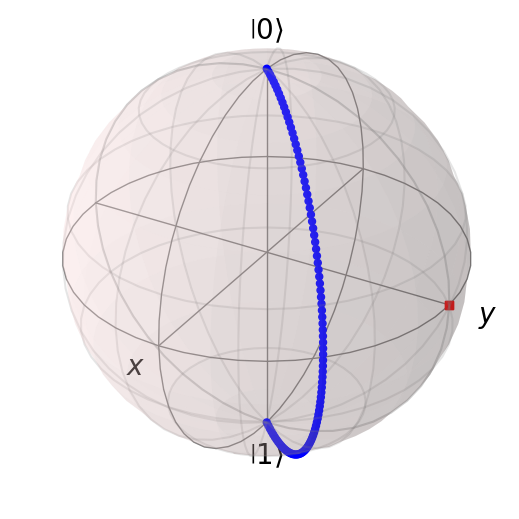

In [4]:
#Importing the Bloch sphere object:
Bloch = qt.Bloch()


theta_list = np.linspace(0,np.pi, 100)
phi = np.pi/4

#X,Y,Z points that are on the Bloch sphere surface.

x,y,z = [],[],[]

for theta in theta_list:
    x.append(np.sin(theta) * np.cos(phi))
    y.append(np.sin(theta) * np.sin(phi))
    z.append(np.cos(theta))


pnts = [x,y, z]

#Add Points on the surface of the sphere:

Bloch.add_points(pnts)
Bloch

#Define initial conditions for one specific point:
#MAY CHANGE THIS TO A LIST OF POINTS LATER... this will be for the colour mesh plot!!!


phi = np.pi/2
theta = np.pi/2




xp,yp,zp = np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)

rho_b = (1/2)*(qt.qeye(N) + xp*qt.sigmax() + yp*qt.sigmay() + zp*qt.sigmaz())

# Compute Bloch vector:

x = qt.expect(qt.sigmax(), rho_b)
y = qt.expect(qt.sigmay(), rho_b)
z = qt.expect(qt.sigmaz(), rho_b)

b_vec = [x, y, z]


Bloch.add_points(b_vec)
Bloch

## Solving:

In [5]:
#Solver:
results = qt.mesolve(Ham,rho_0,tlist,c_ops)

#states:
all_rho_t = results.states

#Matrix elements:
rho_gg = [rho[0,0] for rho in all_rho_t]
rho_ee = [rho[1,1] for rho in all_rho_t]
rho_ge = [rho[0,1] for rho in all_rho_t]
rho_eg = [rho[1,0] for rho in all_rho_t]

## Plots for $\rho_{i,j}$:

C:\Users\otrev\anaconda3\Lib\site-packages\matplotlib\cbook\__init__.py:1340: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


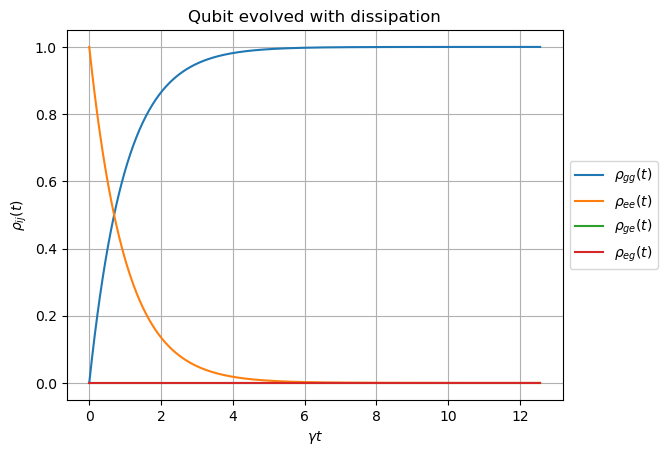

In [6]:
#Comparison of rho_ee and rho_gg
fig1, ax1 = plt.subplots()


ax1.plot(gamma*tlist, rho_gg, label=rf"$\rho_{{gg}}(t)$")
ax1.plot(gamma*tlist, rho_ee, label=rf"$\rho_{{ee}}(t)$")
ax1.plot(gamma*tlist, rho_ge, label=rf"$\rho_{{ge}}(t)$")
ax1.plot(gamma*tlist, rho_eg, label=rf"$\rho_{{eg}}(t)$")

ax1.set_title('Qubit evolved with dissipation')
ax1.set_xlabel(r'$\gamma t$')
ax1.set_ylabel(r'$\rho_{ij}(t)$')
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax1.grid(True)

## Plotting $\rho_{i,j}(t)$ at the surface of the Bloch sphere:

In [7]:
#Set up two initial conditions:
thetas = [np.pi,0.33*np.pi]
phis = np.ones(len(thetas))*0 #Phi is unimportant in this case:


#Define the x,y,z values for the above lists:
x,y,z = [],[],[]

#bloch sphere r scaling:
r_scale = [1,1]

for theta, phi, r in zip(thetas, phis, r_scale):
    x.append(r*np.sin(theta) * np.cos(phi))
    y.append(r*np.sin(theta) * np.sin(phi))
    z.append(r*np.cos(theta))
    

    
rho_b0_list = []
for xi, yi, zi in zip(x, y, z):
    rho = (1/2)*(qt.qeye(N) + xi*qt.sigmax() + yi*qt.sigmay() + zi*qt.sigmaz())
    rho_b0_list.append(rho)
rho_b0_list

[Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
 Qobj data =
 [[0. 0.]
  [0. 1.]],
 Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
 Qobj data =
 [[0.75452071 0.43037101]
  [0.43037101 0.24547929]]]

In [8]:
#mesolve:
#For the first conditions:
results_1 = qt.mesolve(Ham,rho_b0_list[0],tlist,c_ops)

#states:
all_rho_t_1 = results_1.states

#Matrix elements:
rho_gg_1 = [rho[0,0] for rho in all_rho_t_1]
rho_ee_1 = [rho[1,1] for rho in all_rho_t_1]
rho_ge_1 = [rho[0,1] for rho in all_rho_t_1]
rho_eg_1 = [rho[1,0] for rho in all_rho_t_1]


#For the second conditions:

results_2 = qt.mesolve(Ham,rho_b0_list[1],tlist,c_ops)

#states:
all_rho_t_2 = results_2.states

#Matrix elements:
rho_gg_2 = [rho[0,0] for rho in all_rho_t_2]
rho_ee_2 = [rho[1,1] for rho in all_rho_t_2]
rho_ge_2 = [rho[0,1] for rho in all_rho_t_2]
rho_eg_2 = [rho[1,0] for rho in all_rho_t_2]

In [9]:
#Trace distance: I will add others...
#Ground state - evolved state:
ground = qt.basis(2,0) * qt.basis(2,0).dag()


#Trace distance:
trace_dist_1 = [qt.tracedist(rho_t, ground) for rho_t in all_rho_t_1]

trace_dist_2 = [qt.tracedist(rho_t, ground) for rho_t in all_rho_t_2]

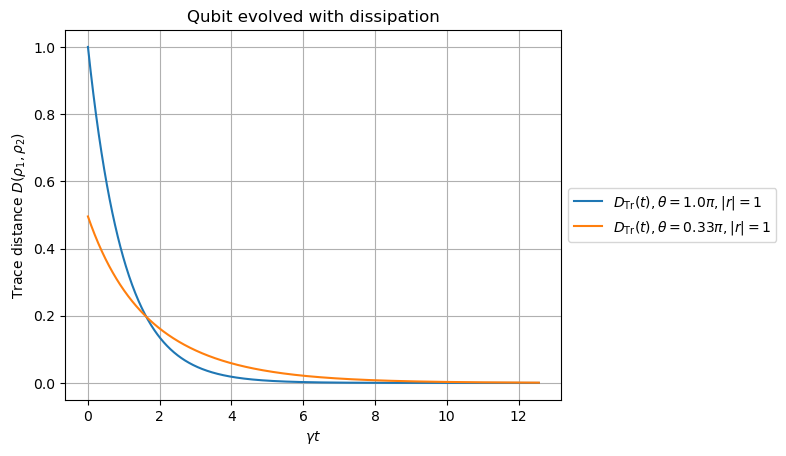

In [10]:
fig2, ax2 = plt.subplots()



ax2.plot(gamma * tlist,trace_dist_1,label=rf"$D_{{\rm Tr}}(t), \theta={thetas[0]/np.pi}\pi, |r|={r_scale[0]}$")
#ax2.plot(gamma*tlist, rho_gg_1, label=rf"$\rho_{{ee}}(t),\theta=\pi/4$")
#ax2.plot(gamma*tlist, rho_gg_2, label=rf"$\rho_{{ee}}(t),\theta=\pi/2$")
ax2.plot(gamma*tlist, trace_dist_2, label=rf"$D_{{\rm Tr}}(t), \theta={thetas[1]/np.pi}\pi, |r|={r_scale[1]}$")

ax2.set_title('Qubit evolved with dissipation')
ax2.set_xlabel(r'$\gamma t$')
ax2.set_ylabel("Trace distance $D(\\rho_1, \\rho_2)$")
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax2.grid(True)

# Plots for several theta: 

This plot will compare theta and theta (to compare a cross over)

In [11]:
#Define/redfine variables:
theta_list = np.linspace(0,np.pi,1000)
tlist = np.linspace(0, 12, 1000)

#Hilbert space dimension:
N = 2

#Constants:
w = 1
gamma = 1

#Operators:
Ham = w*sigma_dag*sigma

#Creatrion/annihilation operator:
sigma = qt.destroy(N)
sigma_dag = sigma.dag()

#Collapse operators:

c_ops = [np.sqrt(gamma) * sigma] 


#Ground state:
ground = qt.basis(2,0) * qt.basis(2,0).dag() #Evolved state

rho_list = []

for theta in theta_list: #Independent of phi!

    x = np.sin(theta)
    y = 0
    z = np.cos(theta)

    rho = 0.5 * (
        qt.qeye(2)
        + x * qt.sigmax()
        + y * qt.sigmay()
        + z * qt.sigmaz())

    rho_list.append(rho)

In [ ]:
results = []
for rh0 in rho_list:
    results.append(qt.mesolve(Ham,rh0,tlist,c_ops))

    
all_rho_t = [res.states for res in results] #Gives a list of all rho(t), for different theta.

#Matrix elements:
#rho_gg = [[rho[0,0] for rho in res.states] for res in results] #Loops overe theta and time.
#rho_ee = [[rho[1,1] for rho in res.states] for res in results]
#rho_ge = [[rho[0,1] for rho in res.states] for res in results]
#rho_eg = [[rho[1,0] for rho in res.states] for res in results]

#Calculate trace distance:

Dist = []

for rho_t in all_rho_t: #Loops over theta         
    D_t = [qt.tracedist(rho, ground) for rho in rho_t] #Loops over time
    Dist.append(D_t)

Dist = np.array(Dist)

In [ ]:
#Detect a cross over: 
#The asympototic parts of the curve dont seem to affect detecting a cross over for this system.

n_theta = Dist.shape[0] #Number of theta

crossing_matrix = np.zeros((n_theta, n_theta), dtype=bool) #A true/false matrix of results to be plotted
crossing_matrix.shape #Check its the expected shape.

for i in range(n_theta):
    for j in range(i + 1, n_theta):#Skips repeated pairs of theta.
        diff = Dist[i] - Dist[j]
        
        #[:-1] ignores final data point and [1:] ignores the first. 
        #A cross between elements 2-3 will record as 2 here:
        has_crossing = np.any(np.sign(diff[:-1]) != np.sign(diff[1:])) #Shifted data points are compared 
        
        crossing_matrix[i, j] = has_crossing
        crossing_matrix[j, i] = has_crossing  # symmetry
        
Mpembas = crossing_matrix.astype(int) #changed True/false to 0/1 to be plotted

In [ ]:
fig3, ax3 = plt.subplots()
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["white", "black"])

image = ax3.imshow(
    Mpembas,
    origin='lower',
    cmap=cmap,   # black/white style
    interpolation='nearest',
    extent=[0, np.pi, 0, np.pi])

ax3.set_xlabel(r"$\theta_{i}$")
ax3.set_ylabel(r"$\theta_{j}$")
ax3.set_title("Mpemba effect phase map")

fig3.colorbar(image, ax=ax3, ticks=[0, 1], label="0 = no Mpemba, 1 = Mpemba")

## Now I will make a relative 'Mpemba strength' plot

This can be achieved by comparing the ratio between initial distance difference and time to cross:

In [ ]:
#Redefine the cmap matrix, for both quantities:
diff_matrix = np.zeros((n_theta, n_theta))
time_matrix = np.zeros((n_theta, n_theta))
strength_matrix = np.zeros((n_theta, n_theta))

#Calculate the initial difference in distance and time of crossing:
for i in range(n_theta):
    for j in range(i + 1, n_theta):#Skips repeated pairs of theta.
        
        diff_0 = Dist[i][0] - Dist[j][0]#Difference at t=0.
        
        diff_matrix[i,j] = diff_0
        diff_matrix[j,i] = diff_0 #Sign doesn't matter, will plot mod as some values may be negative. 
        
        #Time of crossing: 
        diff = Dist[i] - Dist[j]
        crossing_point = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))
        crossing_points = crossing_point[0]#Times where it crossed
        
        if len(crossing_points) > 0:
            first_cross = crossing_points[0]#First cross

            crossing_time = tlist[first_cross]

            time_matrix[i,j] = crossing_time
            time_matrix[j,i] = crossing_time #Again, - values shouldn't matter here 
            
            strength = diff_0 / crossing_time
            strength_matrix[i,j] = np.abs(strength)
            strength_matrix[j,i] = np.abs(strength)
            
        else:
            time_matrix[i,j] = 0
            time_matrix[j,i] = 0

            strength_matrix[i,j] = 0
            strength_matrix[j,i] = 0
            
strength_matrix

In [ ]:
fig4, ax4 = plt.subplots()


image = ax4.imshow(
    strength_matrix,
    origin='lower',
    cmap="viridis",   
    interpolation='nearest',
    extent=[0, np.pi, 0, np.pi])

ax4.set_xlabel(r"$\theta_{i}$")
ax4.set_ylabel(r"$\theta_{j}$")
ax4.set_title("Mpemba effect strength map")

fig4.colorbar(image, ax=ax4, label=r"Relative Strength: $\left| \frac{\Delta D}{t_{\mathrm{cross}}} \right|$")